In [2]:
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
# Standard data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical tests and distributions
from scipy import stats

# For Bayesian modeling (change point detection)
import pymc as pm
import arviz as az

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Libraries imported successfully!")

# ============================================================================
# 2. LOAD THE DATA
# ============================================================================
# Try to load the dataset from the data folder
# Replace the filename with your actual file name if different
file_path = '../data/BrentOilPrices.csv'  # or 'BrentOilPrices.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Data loaded successfully from {file_path}")
except FileNotFoundError:
    # If the file is not found, list available files in data folder
    import os
    print("❌ File not found. Here are the files in your data folder:")
    for f in os.listdir('../data'):
        print(f"  - {f}")
    print("\nPlease update the filename in the code above and rerun this cell.")
    raise

# ============================================================================
# 3. EXPLORE THE DATA STRUCTURE
# ============================================================================
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)

# Show the first few rows
print("\nFirst 5 rows:")
print(df.head())

# Check data types and missing values
print("\nData types and missing values:")
print(df.info())

# Basic statistics
print("\nSummary statistics for numerical columns:")
print(df.describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

✅ Libraries imported successfully!
✅ Data loaded successfully from ../data/BrentOilPrices.csv

DATA OVERVIEW

First 5 rows:
        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63

Data types and missing values:
<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   str    
 1   Price   9011 non-null   float64
dtypes: float64(1), str(1)
memory usage: 140.9 KB
None

Summary statistics for numerical columns:
             Price
count  9011.000000
mean     48.420782
std      32.860110
min       9.100000
25%      19.050000
50%      38.570000
75%      70.090000
max     143.950000

Missing values per column:
Date     0
Price    0
dtype: int64


In [3]:
# ============================================================================
# 4. CONVERT DATE COLUMN TO DATETIME
# ============================================================================
# The date column might be in 'day-month-year' format (e.g., '20-May-87')
# We need to convert it to datetime for time series analysis
# First, check the column name (usually 'Date' or 'date')
date_col = None
for col in df.columns:
    if 'date' in col.lower():
        date_col = col
        break

if date_col is None:
    raise ValueError("No date column found. Please check column names.")
else:
    print(f"Using column '{date_col}' as date.")

# Convert to datetime
# The format may vary; try common formats
try:
    # Try 'day-month-year' (e.g., 20-May-87)
    df['Date'] = pd.to_datetime(df[date_col], format='%d-%b-%y')
except ValueError:
    try:
        # Try 'year-month-day'
        df['Date'] = pd.to_datetime(df[date_col])
    except:
        # Fallback: let pandas infer
        df['Date'] = pd.to_datetime(df[date_col], infer_datetime_format=True)

# Sort by date (just in case)
df = df.sort_values('Date').reset_index(drop=True)

# Set date as index (useful for plotting)
df.set_index('Date', inplace=True)

print("\nDate range:")
print(f"From: {df.index.min()}   To: {df.index.max()}")
print(f"Total days: {len(df)}")

# Show the first few rows after date conversion
print("\nFirst 5 rows with datetime index:")
print(df.head())

Using column 'Date' as date.

Date range:
From: 1987-05-20 00:00:00   To: 2022-11-14 00:00:00
Total days: 9011

First 5 rows with datetime index:
            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63


In [7]:
# ============================================================================
# 4. UNDERSTAND YOUR DATA STRUCTURE
# ============================================================================
# Your data has:
# - Index: Date (already a datetime index)
# - Column: Price (oil price in USD per barrel)

print("="*60)
print("DATA STRUCTURE CONFIRMED")
print("="*60)
print(f"Index type: {type(df.index)}")
print(f"First index value: {df.index[0]}")
print(f"Last index value: {df.index[-1]}")
print(f"Total rows: {len(df)}")

# Show the first few rows
print("\nFirst 5 rows of data:")
print(df.head())

# Show the last few rows
print("\nLast 5 rows of data:")
print(df.tail())

# Basic statistics
print("\nSummary statistics for Price:")
print(df['Price'].describe())

DATA STRUCTURE CONFIRMED
Index type: <class 'pandas.DatetimeIndex'>
First index value: 1987-05-20 00:00:00
Last index value: 2022-11-14 00:00:00
Total rows: 9011

First 5 rows of data:
            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63

Last 5 rows of data:
            Price
Date             
2022-11-08  96.85
2022-11-09  93.05
2022-11-10  94.25
2022-11-11  96.37
2022-11-14  93.59

Summary statistics for Price:
count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64


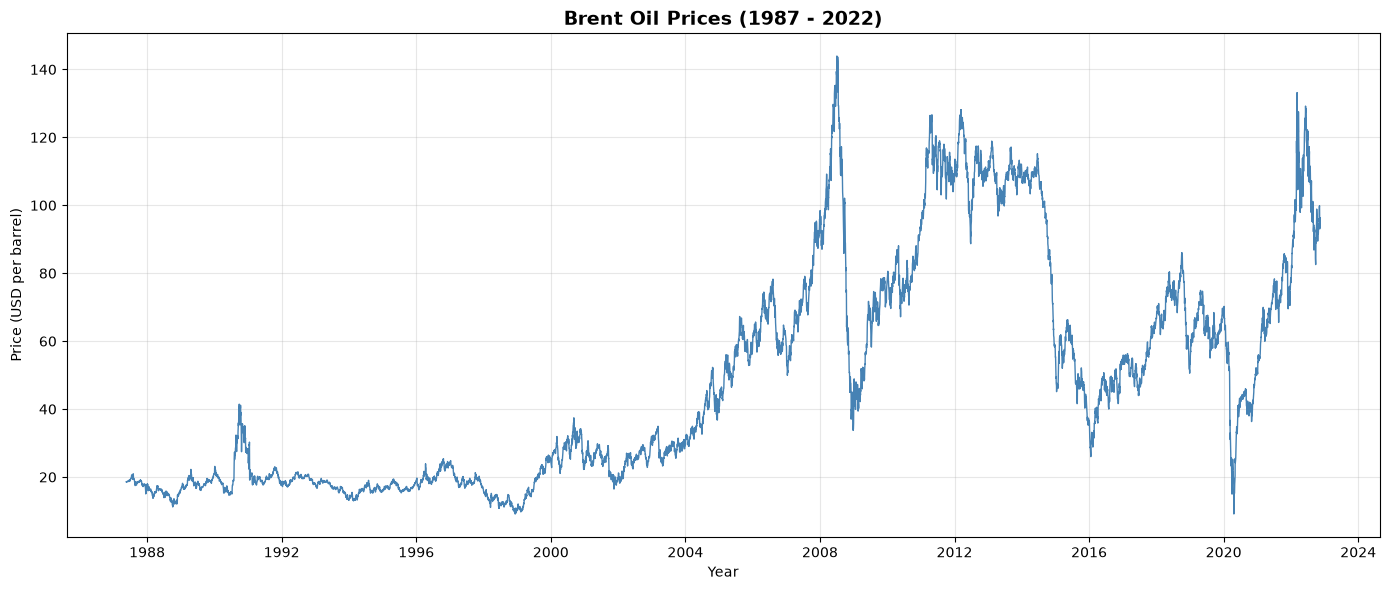

Minimum price: $9.10
Maximum price: $143.95
Average price: $48.42


In [8]:
# ============================================================================
# 5. PLOT THE RAW PRICE SERIES
# ============================================================================
# Visualize Brent oil price over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Price'], color='steelblue', linewidth=1)
plt.title('Brent Oil Prices (1987 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD per barrel)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Minimum price: ${df['Price'].min():.2f}")
print(f"Maximum price: ${df['Price'].max():.2f}")
print(f"Average price: ${df['Price'].mean():.2f}")

Number of trading days (returns): 9010
Mean log return: 0.000179
Std dev of log returns: 0.025532


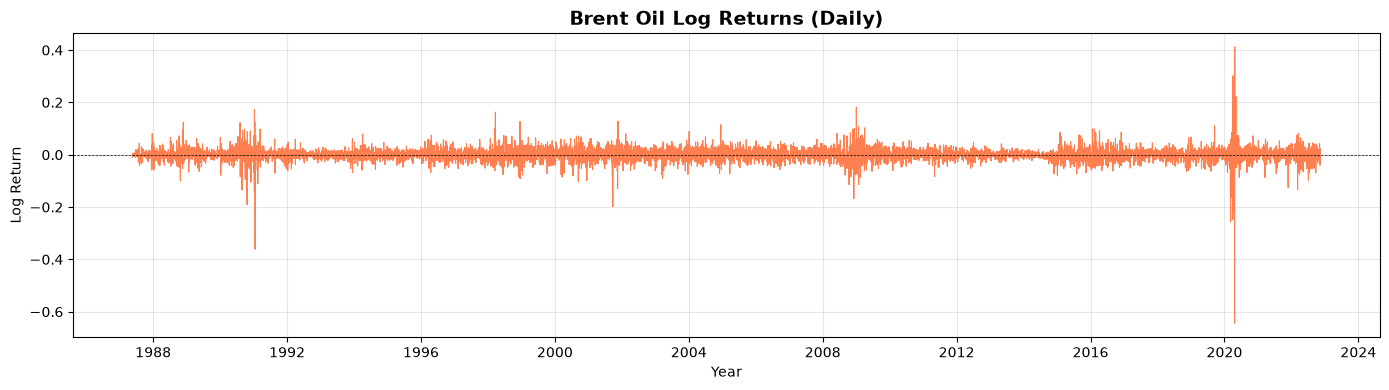

In [9]:
# ============================================================================
# 6. CALCULATE AND PLOT LOG RETURNS
# ============================================================================
# Log returns = log(Price_t) - log(Price_{t-1})
# This makes the series more stationary and shows volatility clustering

# Calculate log returns
df['Log_Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))

# Remove the first row (NaN from shift)
df_returns = df.dropna(subset=['Log_Return'])

print(f"Number of trading days (returns): {len(df_returns)}")
print(f"Mean log return: {df_returns['Log_Return'].mean():.6f}")
print(f"Std dev of log returns: {df_returns['Log_Return'].std():.6f}")

# Plot log returns
plt.figure(figsize=(14, 4))
plt.plot(df_returns.index, df_returns['Log_Return'], color='coral', linewidth=0.8)
plt.title('Brent Oil Log Returns (Daily)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Log Return')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================================
# 7. STATIONARITY TESTING
# ============================================================================
# A stationary time series has constant mean and variance over time.
# Most statistical models require stationarity.
from statsmodels.tsa.stattools import adfuller

print("="*60)
print("AUGMENTED DICKEY-FULLER TEST FOR STATIONARITY")
print("="*60)

# Test for Price (raw)
result_price = adfuller(df['Price'].dropna())
print("\n--- Raw Price ---")
print(f"ADF Statistic: {result_price[0]:.4f}")
print(f"P-value: {result_price[1]:.4f}")
print(f"Critical Values:")
for key, value in result_price[4].items():
    print(f"  {key}: {value:.4f}")

if result_price[1] < 0.05:
    print("✅ The Price series is stationary (reject null hypothesis).")
else:
    print("❌ The Price series is NOT stationary (fail to reject null).")

# Test for Log Returns (which are usually stationary)
result_ret = adfuller(df_returns['Log_Return'])
print("\n--- Log Returns ---")
print(f"ADF Statistic: {result_ret[0]:.4f}")
print(f"P-value: {result_ret[1]:.4f}")
print(f"Critical Values:")
for key, value in result_ret[4].items():
    print(f"  {key}: {value:.4f}")

if result_ret[1] < 0.05:
    print("✅ Log Returns are stationary (reject null).")
else:
    print("❌ Log Returns are NOT stationary (fail to reject).")

AUGMENTED DICKEY-FULLER TEST FOR STATIONARITY

--- Raw Price ---
ADF Statistic: -1.9939
P-value: 0.2893
Critical Values:
  1%: -3.4311
  5%: -2.8619
  10%: -2.5669
❌ The Price series is NOT stationary (fail to reject null).

--- Log Returns ---
ADF Statistic: -16.4271
P-value: 0.0000
Critical Values:
  1%: -3.4311
  5%: -2.8619
  10%: -2.5669
✅ Log Returns are stationary (reject null).


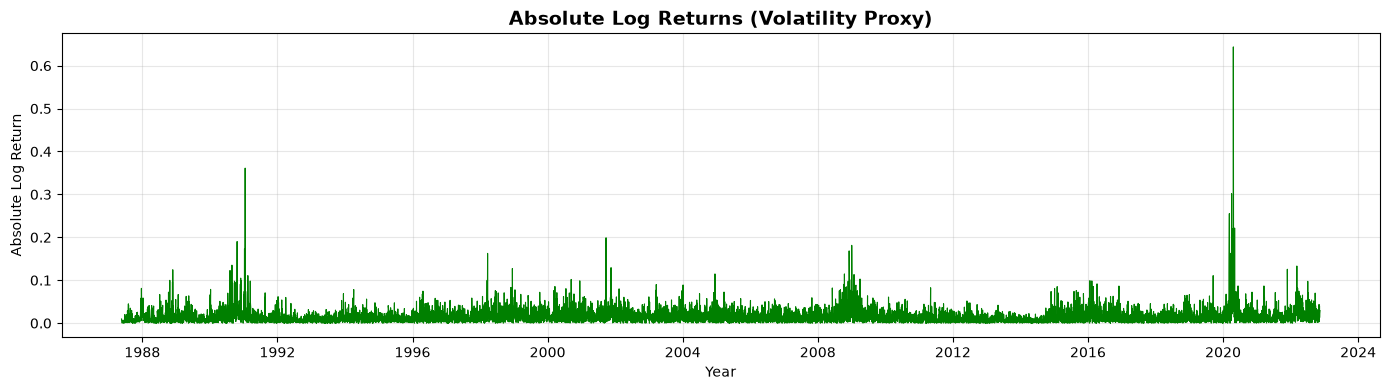

Mean absolute log return: 0.016510
Max absolute log return: 0.643699


In [12]:
# ============================================================================
# 8. VOLATILITY CLUSTERING
# ============================================================================
# Volatility clustering = high-volatility periods followed by high volatility

# Calculate absolute log returns as a proxy for volatility
df_returns['Abs_Log_Return'] = np.abs(df_returns['Log_Return'])

plt.figure(figsize=(14, 4))
plt.plot(df_returns.index, df_returns['Abs_Log_Return'], color='green', linewidth=0.8)
plt.title('Absolute Log Returns (Volatility Proxy)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Absolute Log Return')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean absolute log return: {df_returns['Abs_Log_Return'].mean():.6f}")
print(f"Max absolute log return: {df_returns['Abs_Log_Return'].max():.6f}")

In [13]:
# ============================================================================
# 9. SAVE THE DATA FOR NEXT STEPS
# ============================================================================
# We'll need the data with log returns for the change point model
df.to_csv('../data/brent_oil_with_returns.csv')
print("✅ Data with log returns saved to: ../data/brent_oil_with_returns.csv")

✅ Data with log returns saved to: ../data/brent_oil_with_returns.csv
